In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
monthly_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

In [4]:
print(monthly_df.head())
print(monthly_df.shape)

        Month  Passenger Count
0  1999-07-01          3976746
1  1999-08-01          3972694
2  1999-09-01          3341964
3  1999-10-01          3468846
4  1999-11-01          3145240
(324, 2)


In [5]:
monthly_df["Month"] = pd.to_datetime(monthly_df["Month"])

In [6]:
monthly_df = monthly_df.sort_values("Month").reset_index(drop=True)

In [7]:
print(monthly_df.head())
print(monthly_df.tail())

       Month  Passenger Count
0 1999-07-01          3976746
1 1999-08-01          3972694
2 1999-09-01          3341964
3 1999-10-01          3468846
4 1999-11-01          3145240
         Month  Passenger Count
319 2026-02-01          3701198
320 2026-03-01          4546149
321 2026-04-01          4504215
322 2026-05-01          4884065
323 2026-06-01          5203386


In [8]:
split_index = int(len(monthly_df) * 0.8)

train = monthly_df.iloc[:split_index].copy()
test = monthly_df.iloc[split_index:].copy()

In [9]:
print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 259
Testing rows: 65


In [10]:
print("Training period:")
print(train["Month"].min(), "to", train["Month"].max())

print("\nTesting period:")
print(test["Month"].min(), "to", test["Month"].max())

Training period:
1999-07-01 00:00:00 to 2021-01-01 00:00:00

Testing period:
2021-02-01 00:00:00 to 2026-06-01 00:00:00


In [11]:
monthly_df["Previous Month Passengers"] = (
    monthly_df["Passenger Count"].shift(1)
)

In [12]:
print(monthly_df.head(10))

       Month  Passenger Count  Previous Month Passengers
0 1999-07-01          3976746                        NaN
1 1999-08-01          3972694                  3976746.0
2 1999-09-01          3341964                  3972694.0
3 1999-10-01          3468846                  3341964.0
4 1999-11-01          3145240                  3468846.0
5 1999-12-01          3077142                  3145240.0
6 2000-01-01          2781129                  3077142.0
7 2000-02-01          2725393                  2781129.0
8 2000-03-01          3294029                  2725393.0
9 2000-04-01          3392617                  3294029.0


In [13]:
train = monthly_df.iloc[:split_index].copy()
test = monthly_df.iloc[split_index:].copy()

In [14]:
y_test = test["Passenger Count"]
y_pred_baseline = test["Previous Month Passengers"]

In [15]:
print("Actual:")
print(y_test.head())

print("\nBaseline prediction:")
print(y_pred_baseline.head())

Actual:
259     736324
260    1160020
261    1455944
262    1739021
263    2245539
Name: Passenger Count, dtype: int64

Baseline prediction:
259     769908.0
260     736324.0
261    1160020.0
262    1455944.0
263    1739021.0
Name: Previous Month Passengers, dtype: float64


In [16]:
mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

print("Baseline MAE:", mae)

Baseline MAE: 326970.92307692306


In [17]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

print("Baseline RMSE:", rmse)

Baseline RMSE: 384439.04171943024


In [18]:
print("Baseline Model Results")
print("----------------------")
print("MAE :", mae)
print("RMSE:", rmse)

Baseline Model Results
----------------------
MAE : 326970.92307692306
RMSE: 384439.04171943024


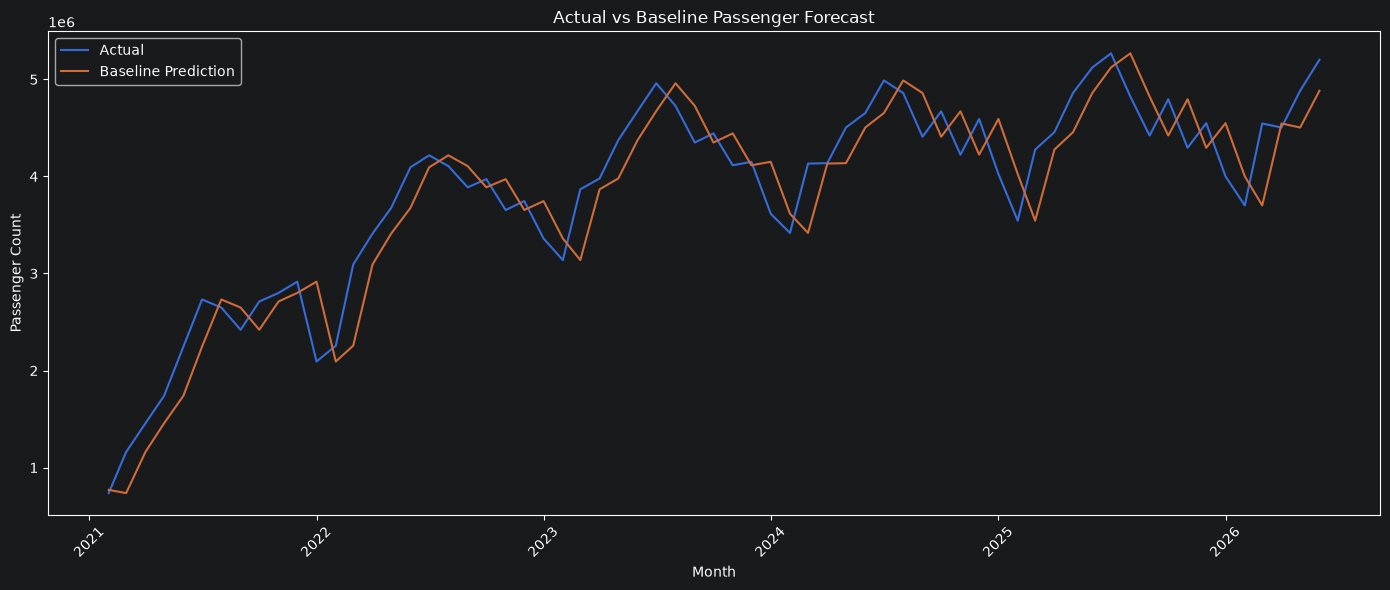

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Month"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Month"],
    y_pred_baseline,
    label="Baseline Prediction"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Actual vs Baseline Passenger Forecast")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observations

1. The data covers the period from around 2021 to mid-2026, representing a solid recovery phase from the COVID-19 pandemic during which the number of passengers per month increased from around 1 million to over 5 million.

2. The other main feature of a baseline prediction is that it is always one month late, which is what a lag-1 model does. It can only respond to a change in the passenger trend, it cannot predict it.

3. The baseline is doing relatively well during period of gradual and steady growth (mid-2022 – 2023) when month-to-month changes are small.

4. It is most difficult at sharp turning points, especially at dips and recoveries that appear around 2023-2024 and 2025-2026, respectively, but which are “one month late”.

5. The data shows a clear trend in the real data, with peaks and troughs occurring at regular intervals each year. This seasonality is not explicitly modeled with the baseline, only picked up "by chance" if the preceding month happened to be similar.

6. Because of the overall upwards trend, the baseline is structurally biased. It is consistently predicting a number lower than reality during growth periods; last month's number always being lower than this month's.

Baseline MAE: 326970.92307692306
Baseline RMSE: 384439.04171943024